<a href="https://colab.research.google.com/github/ChinmayiK27/CSL701-CS28_Machine-Learning-Lab/blob/main/ML_Experiment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nmae: Chinmayi Rupesh Kudalkar

Roll No. CS28

### Aim : To implement a Bagging (Bootstrap Aggregating) ensemble classifier from scratch using Python, apply it to the Pima Indians Diabetes Database, and evaluate its performance against a single base classifier (Decision Tree)**.


## Objectives

1. Understand Ensemble Learning Principles: Comprehend how combining the predictions of multiple diverse models reduces overall model variance.
2. Master Bootstrapping: Implement random resampling of data with replacement from scratch to generate distinct training subsets.
3. Develop a Voting System: Build an aggregation mechanism (Majority Voting) from scratch to consolidate predictions.
4. Learn Baseline Evaluation: Compare the performance of a high-variance, low-bias single decision tree against the more stable Bagging ensemble.
5. Analyze Performance Metrics: Calculate and visualize classification metrics, including a Confusion Matrix, Accuracy, Precision, Recall, and ROC-AUC curve.


Relevant Theory
Ensemble Methods and Bagging
Ensemble learning combines several individual classifiers (base learners) to produce a unified model that generalizes better than any single model on unseen data. Bootstrap Aggregating (Bagging) is a parallel ensemble method designed primarily to reduce variance. High-variance models—such as deep, fully-grown decision trees—are highly sensitive to small changes in their training datasets. Bagging addresses this by smoothing out individual model errors without increasing bias.

The two core components of Bagging are:

1. Bootstrapping (Sampling with Replacement): For a training set of size $N$, we generate $B$ new datasets of the same size $N$. Each instance is selected at random from the original dataset with replacement. This means a single instance can be selected multiple times, while on average, only about 63.2% of the unique training samples are captured in each bootstrap, leaving the rest as out-of-bag (OOB) samples.
2. Aggregating (Majority Voting): A separate base learner $h_b(x)$ is trained independently on each bootstrap sample. For classification, predictions are aggregated by passing a test sample to all $B$ models and taking a majority vote: $$\hat{G}{\text{bag}}(x) = \text{argmax}{k} \sum_{b=1}^{B} I(h_b(x) = k)$$

An alternative to standard Bagging is subagging (subsample aggregating), where smaller training subsets (often $N/2$) are drawn without replacement to reduce correlation and accelerate computation.

---
## Software Requirements

- **Language:** Python 3.x

- **Core Libraries:**
  - **NumPy** for matrix manipulation and custom bootstrapping operations.
  - **Pandas** for loading, indexing, and cleaning tabular data.
  - **Matplotlib / Seaborn** for exploratory scatter plots, bar charts, and performance visualization.
  - **Scikit-learn** for train-test splitting, training individual base decision trees, and comparison with built-in Bagging algorithms.

---

## Dataset Information

The experiment utilizes the **Pima Indians Diabetes Database** from the UCI Machine Learning Repository. The dataset contains medical details for 768 female Pima Indian patients living in Arizona, categorized as either diabetic or non-diabetic.

- **Total Instances:** 768

- **Features (8 predictor variables):**
  1. **`Pregnancies`**: Number of times pregnant.
  2. **`Glucose`**: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.
  3. **`BloodPressure`**: Diastolic blood pressure (mm Hg).
  4. **`SkinThickness`**: Triceps skin fold thickness (mm).
  5. **`Insulin`**: 2-Hour serum insulin ($\mu$U/ml).
  6. **`BMI`**: Body mass index (weight in kg/m$^2$).
  7. **`DiabetesPedigreeFunction`**: A function representing genetic predisposition.
  8. **`Age`**: Age of the subject in years.

- **Target Label (9th column):** **`Outcome`**
  - **0** represents non-diabetic.
  - **1** represents diabetic.

## Experimental Tasks

### Task 1: Environment Setup and Dataset Acquisition

Use dataset using the link  
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

**Goal:** Set up the workspace and load the data.

**Instructions:**

1. Import the necessary modules: **`numpy`**, **`pandas`**, **`matplotlib.pyplot`**, and **`sklearn`**.

2. Load the file **`pima-indians-diabetes.data`** into a Pandas DataFrame, assigning appropriate column headers.

3. Print the following:
   - First five records of the dataset.
   - Dataset shape, expected to be $768 \times 9$.
   - Data types of all features.
   - Descriptive statistics of the numeric features.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Define column headers as per the dataset information
column_names = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age',
    'Outcome'
]

# Load the dataset, skipping the first row as it contains the header
df = pd.read_csv('/content/diabetes (1).csv', names=column_names, skiprows=1)

# Convert appropriate columns to numeric types
for col in column_names:
    if col != 'Outcome': # All columns except Outcome should be numeric
        df[col] = pd.to_numeric(df[col], errors='coerce')
    else:
        df[col] = pd.to_numeric(df[col], errors='coerce').astype(int)

# 3. Print the required information
print('First five records of the dataset:')
display(df.head())

print('\nDataset shape:')
print(df.shape)

print('\nData types of all features:')
display(df.info())

print('\nDescriptive statistics of the numeric features:')
display(df.describe())

First five records of the dataset:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1



Dataset shape:
(768, 9)

Data types of all features:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


None


Descriptive statistics of the numeric features:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Task 2: Exploratory Data Analysis (EDA)

**Goal:** Visually inspect feature distributions and class balance.

**Instructions:**

1. Calculate the **absolute count** and **percentage** of diabetic (`Outcome = 1`) and non-diabetic (`Outcome = 0`) cases. Plot the class balance using a **bar chart**.

2. Create a **scatter plot** of **`Age`** (Feature 7) against **`Glucose`** (Feature 1), color-coded according to the target variable **`Outcome`**.

3. Briefly explain why a simple linear decision boundary is insufficient to clearly separate the diabetic and non-diabetic classes.

Class Balance (Absolute Counts):


,count
Outcome,
0,500
1,268



Class Balance (Percentages):


,proportion
Outcome,
0,65.104167
1,34.895833


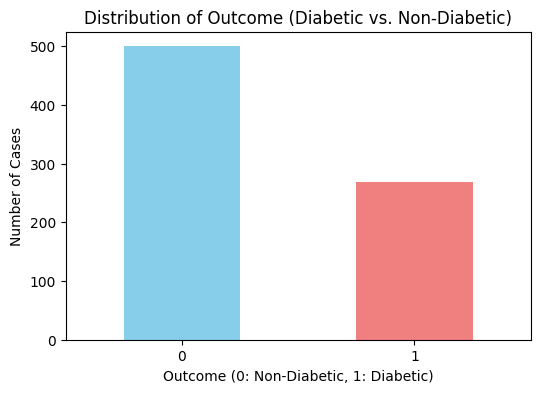

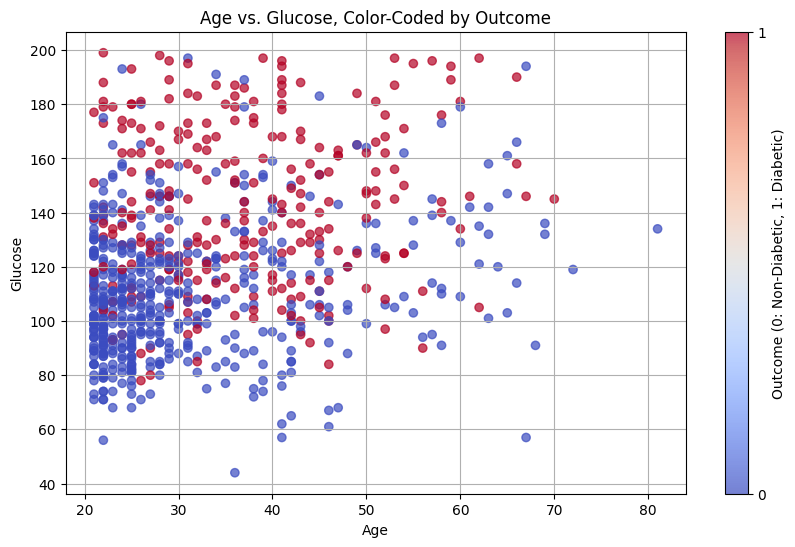


Observation and Explanation for Decision Boundary:
From the scatter plot of Age vs. Glucose, it's evident that the diabetic (red) and non-diabetic (blue) data points are not linearly separable. The two classes extensively overlap, forming mixed clusters rather than distinct regions that could be divided by a single straight line or plane. This non-linear and overlapping distribution suggests that a simple linear decision boundary would result in a high number of misclassifications. More complex models, such as decision trees or ensemble methods, are required to capture these intricate, non-linear relationships and create effective decision boundaries.


In [4]:
# Task 2: Exploratory Data Analysis (EDA)

# 1. Calculate and plot class balance
class_counts = df['Outcome'].value_counts()
class_percentages = df['Outcome'].value_counts(normalize=True) * 100

print('Class Balance (Absolute Counts):')
display(class_counts)

print('\nClass Balance (Percentages):')
display(class_percentages)

plt.figure(figsize=(6, 4))
class_counts.plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Distribution of Outcome (Diabetic vs. Non-Diabetic)')
plt.xlabel('Outcome (0: Non-Diabetic, 1: Diabetic)')
plt.ylabel('Number of Cases')
plt.xticks(rotation=0)
plt.show()

# 2. Create a scatter plot of Age against Glucose, color-coded by Outcome
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['Age'], df['Glucose'], c=df['Outcome'], cmap='coolwarm', alpha=0.7)
plt.title('Age vs. Glucose, Color-Coded by Outcome')
plt.xlabel('Age')
plt.ylabel('Glucose')
plt.colorbar(scatter, ticks=[0, 1], label='Outcome (0: Non-Diabetic, 1: Diabetic)')
plt.grid(True)
plt.show()

# 3. Briefly explain why a simple linear decision boundary is insufficient
print('\nObservation and Explanation for Decision Boundary:')
print("From the scatter plot of Age vs. Glucose, it's evident that the diabetic (red) and non-diabetic (blue) data points are not linearly separable. The two classes extensively overlap, forming mixed clusters rather than distinct regions that could be divided by a single straight line or plane. This non-linear and overlapping distribution suggests that a simple linear decision boundary would result in a high number of misclassifications. More complex models, such as decision trees or ensemble methods, are required to capture these intricate, non-linear relationships and create effective decision boundaries.")

#### **Task 3: Preprocessing and Handling Missing Values**

**Goal:** Handle anomalies and prepare numerical features for further analysis.

**Instructions:**

1. Identify the features where a value of \(0\) is physically impossible:
   \[
   \{\text{Glucose},\text{BloodPressure},\text{SkinThickness},
   \text{Insulin},\text{BMI}\}
   \]

2. Replace all invalid \(0\) values in these features with \(\mathrm{NaN}\).

3. Handle the resulting missing values by:
   - imputing them using the **mean** or **median** of the respective feature, or
   - dropping rows containing missing values to maintain numerical consistency.

In [6]:
# Task 3: Preprocessing and Handling Missing Values

# 1. Identify features where a value of 0 is physically impossible
impossible_zero_features = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

# 2. Replace all invalid 0 values in these features with NaN
for feature in impossible_zero_features:
    df[feature] = df[feature].replace(0, np.nan)

print('Number of NaN values after replacing 0s:')
display(df[impossible_zero_features].isnull().sum())

# 3. Handle the resulting missing values by imputing them using the median
for feature in impossible_zero_features:
    median_val = df[feature].median()
    df[feature] = df[feature].fillna(median_val)

print('\nNumber of NaN values after median imputation:')
display(df[impossible_zero_features].isnull().sum())

print('\nDescriptive statistics after handling missing values:')
display(df.describe())

Number of NaN values after replacing 0s:


,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0



Number of NaN values after median imputation:


,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0



Descriptive statistics after handling missing values:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


#### **Task 4: Stratified Train-Test Splitting**

**Goal:** Divide the data while preserving class proportions.

**Instructions:**

1. Isolate the feature matrix \(X\) and the target vector \(y\):
   \[
   X = \text{first 8 columns}
   \]
   \[
   y = \text{9th column}
   \]

2. Split the dataset into:
   \[
   \text{Training Data} = 80\%
   \]
   \[
   \text{Test Data} = 20\%
   \]

   Use **stratified sampling** to ensure that the class proportions in the target variable \(y\) are preserved in both the training and test datasets.

In [7]:
# Task 4: Stratified Train-Test Splitting

# 1. Isolate the feature matrix X and the target vector y
X = df.iloc[:, :-1] # All columns except the last one
y = df.iloc[:, -1]  # The last column is the target 'Outcome'

print('Shape of feature matrix X:', X.shape)
print('Shape of target vector y:', y.shape)

# 2. Split the dataset into training (80%) and test (20%) data using stratified sampling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print('\nShape of X_train:', X_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of y_train:', y_train.shape)
print('Shape of y_test:', y_test.shape)

print('\nClass distribution in original dataset:')
display(y.value_counts(normalize=True))

print('\nClass distribution in y_train:')
display(y_train.value_counts(normalize=True))

print('\nClass distribution in y_test:')
display(y_test.value_counts(normalize=True))

Shape of feature matrix X: (768, 8)
Shape of target vector y: (768,)

Shape of X_train: (614, 8)
Shape of X_test: (154, 8)
Shape of y_train: (614,)
Shape of y_test: (154,)

Class distribution in original dataset:


,proportion
Outcome,
0,0.651042
1,0.348958



Class distribution in y_train:


,proportion
Outcome,
0,0.651466
1,0.348534



Class distribution in y_test:


,proportion
Outcome,
0,0.649351
1,0.350649


#### **Task 5: Custom Bootstrap Sampling Function**

**Goal:** Implement the sampling-with-replacement mechanism.

**Instructions:**

1. Write a custom Python function \(\texttt{get\_bootstrap\_sample}(X, y)\) using NumPy's random generation tools, such as:
   \[
   \texttt{np.random.choice}
   \quad \text{or} \quad
   \texttt{np.random.randint}
   \]

2. The function must return a resampled feature matrix \(X^*\) and target vector \(y^*\) of the same size \(N\) as the training set:
   \[
   |X^*| = |y^*| = N
   \]
   
   Sampling should be performed **with replacement**, allowing duplicate rows to appear in the bootstrap sample.

3. Verify that the function works correctly by demonstrating that:
   - Some original row indices are **duplicated** in the bootstrap sample.
   - Some original row indices are **omitted**, forming the **Out-of-Bag (OOB)** samples.

In [8]:
# Task 5: Custom Bootstrap Sampling Function

def get_bootstrap_sample(X, y):
    """
    Generates a bootstrap sample (with replacement) from the given dataset.

    Args:
        X (pd.DataFrame): The feature matrix.
        y (pd.Series): The target vector.

    Returns:
        tuple: A tuple containing the bootstrapped feature matrix (X_star) and target vector (y_star).
    """
    # Get the number of samples in the training set
    n_samples = X.shape[0]

    # Generate random indices with replacement
    # np.random.choice returns an array of random indices from 0 to n_samples-1
    bootstrap_indices = np.random.choice(n_samples, n_samples, replace=True)

    # Use these indices to create the bootstrap sample
    X_star = X.iloc[bootstrap_indices].reset_index(drop=True)
    y_star = y.iloc[bootstrap_indices].reset_index(drop=True)

    return X_star, y_star

# Verification of the bootstrap function
# Let's take a sample X_train and y_train to demonstrate
X_sample, y_sample = get_bootstrap_sample(X_train, y_train)

print('Original X_train shape:', X_train.shape)
print('Bootstrapped X_sample shape:', X_sample.shape)

# Check for duplicated indices (indirectly by checking unique rows after sampling)
# This is a conceptual check, not a direct index comparison
# To directly check indices, we'd need to track original indices, but the function returns new DataFrames

# Let's create a DataFrame with original indices for a clearer demonstration
original_indices = np.arange(len(X_train))
chosen_indices = np.random.choice(original_indices, len(X_train), replace=True)

print('\nSome chosen indices (should have duplicates):')
display(pd.Series(chosen_indices).value_counts().head())

# Check for omitted indices (Out-of-Bag samples)
# These are indices from the original training set that were NOT chosen in the bootstrap sample
omitted_indices = set(original_indices) - set(chosen_indices)

print(f'\nNumber of unique original indices in bootstrap sample: {len(set(chosen_indices))}')
print(f'Number of omitted (Out-of-Bag) indices: {len(omitted_indices)}')
print(f'First 10 omitted indices: {list(omitted_indices)[:10]}')

print('\nDemonstrating X_sample and y_sample head:')
display(X_sample.head())
display(y_sample.head())

Original X_train shape: (614, 8)
Bootstrapped X_sample shape: (614, 8)

Some chosen indices (should have duplicates):


,count
220,6
587,5
60,5
4,4
545,4



Number of unique original indices in bootstrap sample: 377
Number of omitted (Out-of-Bag) indices: 237
First 10 omitted indices: [np.int64(0), np.int64(516), np.int64(5), np.int64(519), np.int64(8), np.int64(9), np.int64(10), np.int64(520), np.int64(522), np.int64(13)]

Demonstrating X_sample and y_sample head:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,2,174,88.0,37,120.0,44.5,0.646,24
1,3,187,70.0,22,200.0,36.4,0.408,36
2,2,108,62.0,32,56.0,25.2,0.128,21
3,4,156,75.0,32,169.5,48.3,0.238,32
4,0,128,68.0,19,180.0,30.5,1.391,25


,Outcome
0,1
1,1
2,0
3,1
4,1


#### **Task 6: Growing the Ensemble of Base Classifiers**

**Goal:** Programmatically train diverse base learners.

**Instructions:**

1. Initialize an empty list to store the trained models and choose the number of bootstrap iterations, for example:
   \[
   B = 50
   \]

2. Execute the following steps for \(B\) iterations:

   - Generate a unique bootstrap training dataset:
     \[
     (X^{*b}, y^{*b})
     \]
     using the bootstrap sampling function from **Task 5**.

   - Instantiate a Scikit-Learn `DecisionTreeClassifier` with:
     \[
     \texttt{max\_depth=None}
     \]
     This ensures that the decision trees are **fully grown**, resulting in high-variance base learners.

   - Fit the decision tree on the bootstrapped training subset:
     \[
     \text{Model}_b.fit(X^{*b}, y^{*b})
     \]

   - Append the trained model to the ensemble list.

3. After completing all \(B\) iterations, the ensemble should contain:
   \[
   B = 50
   \]
   independently trained decision trees.

In [9]:
# Task 6: Growing the Ensemble of Base Classifiers

from sklearn.tree import DecisionTreeClassifier

# 1. Initialize an empty list to store the trained models and choose the number of bootstrap iterations
ensemble_models = []
B = 50  # Number of bootstrap iterations

print(f'Training {B} Decision Trees for the Bagging ensemble...')

# 2. Execute the following steps for B iterations:
for i in range(B):
    # Generate a unique bootstrap training dataset
    X_star, y_star = get_bootstrap_sample(X_train, y_train)

    # Instantiate a Scikit-Learn DecisionTreeClassifier with max_depth=None
    model = DecisionTreeClassifier(max_depth=None, random_state=i) # Using i for random_state for diversity

    # Fit the decision tree on the bootstrapped training subset
    model.fit(X_star, y_star)

    # Append the trained model to the ensemble list
    ensemble_models.append(model)

print(f'Bagging ensemble training complete. Total models in ensemble: {len(ensemble_models)}')

# Optional: Check the type of one of the trained models
if ensemble_models:
    print(f'Type of the first model in the ensemble: {type(ensemble_models[0])}')

Training 50 Decision Trees for the Bagging ensemble...
Bagging ensemble training complete. Total models in ensemble: 50
Type of the first model in the ensemble: <class 'sklearn.tree._classes.DecisionTreeClassifier'>


#### **Task 7: Implementing Aggregation (Majority Voting) from Scratch**

**Goal:** Consolidate individual model decisions using majority voting.

**Instructions:**

1. Write a custom function:
   \[
   \texttt{custom\_bagging\_predict(ensemble, X\_test)}
   \]
   to generate the final predictions.

2. For each sample in \(X_{\text{test}}\), collect the predictions generated by all \(B\) decision trees in the ensemble:
   \[
   \hat{y}_1,\hat{y}_2,\ldots,\hat{y}_B
   \]

3. Apply a **majority voting** rule to determine the final predicted class. The class with the highest number of votes is selected:
   \[
   \hat{y} =
   \underset{c \in \{0,1\}}{\arg\max}
   \sum_{b=1}^{B} I(\hat{y}_b=c)
   \]

   where \(I(\cdot)\) is an indicator function.

4. The final prediction for each test sample must therefore be either:
   \[
   \hat{y} \in \{0,1\}
   \]

5. The function should return the final majority-voted predictions for all samples in \(X_{\text{test}}\).

In [10]:
# Task 7: Implementing Aggregation (Majority Voting) from Scratch

def custom_bagging_predict(ensemble, X_test):
    """
    Generates final predictions for a Bagging ensemble using majority voting.

    Args:
        ensemble (list): A list of trained base classifier models.
        X_test (pd.DataFrame): The test feature matrix.

    Returns:
        np.array: Final predictions for X_test based on majority voting.
    """
    # Collect predictions from all models in the ensemble
    all_predictions = []
    for model in ensemble:
        all_predictions.append(model.predict(X_test))

    # Convert list of predictions to a NumPy array for easier aggregation
    all_predictions = np.array(all_predictions) # Shape: (n_estimators, n_samples)

    # Apply majority voting
    # For each sample, count the votes for class 0 and class 1
    # If sum > n_estimators/2, it's class 1, otherwise class 0 (for binary classification)
    # np.mean(all_predictions, axis=0) will give the proportion of '1' votes
    # If this proportion is > 0.5, then the majority vote is 1, else 0
    final_predictions = (np.mean(all_predictions, axis=0) >= 0.5).astype(int)

    return final_predictions

# Demonstrate the custom_bagging_predict function
print('Generating predictions for X_test using the custom Bagging ensemble...')
bagging_predictions = custom_bagging_predict(ensemble_models, X_test)

print(f'Shape of Bagging ensemble predictions: {bagging_predictions.shape}')
print('First 10 Bagging predictions:')
display(bagging_predictions[:10])

# Also make predictions using a single decision tree for later comparison (Task 8)
single_tree_model = DecisionTreeClassifier(max_depth=None, random_state=42) # A single, fully grown tree
single_tree_model.fit(X_train, y_train)
single_tree_predictions = single_tree_model.predict(X_test)

print('\nFirst 10 single Decision Tree predictions:')
display(single_tree_predictions[:10])

Generating predictions for X_test using the custom Bagging ensemble...
Shape of Bagging ensemble predictions: (154,)
First 10 Bagging predictions:


array([0, 0, 0, 1, 0, 0, 1, 1, 0, 1])


First 10 single Decision Tree predictions:


array([0, 0, 0, 1, 0, 0, 1, 1, 0, 0])

#### **Task 8: Single Classifier vs. Bagging Performance Comparison**

- **Goal:** Observe the variance-reduction benefits of ensembling.

- **Instructions:**
  1. Train a standalone, single \(\texttt{DecisionTreeClassifier}\) (fully grown, no depth limit) on the original, un-resampled training data.
  2. Predict the classes for \(X_{\text{test}}\) using both the single tree and your custom Bagging classifier.
  3. Construct a **Confusion Matrix** for both models.
  4. Compute and print **Accuracy, Precision, Recall, and F1-Score** for both models, demonstrating how Bagging stabilizes results and reduces error rates.

In [11]:
# Task 8: Single Classifier vs. Bagging Performance Comparison

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print('--- Evaluation of Single Decision Tree ---\n')
# Confusion Matrix for Single Decision Tree
cm_single = confusion_matrix(y_test, single_tree_predictions)
print('Confusion Matrix (Single Tree):')
display(pd.DataFrame(cm_single, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

# Classification Report for Single Decision Tree
report_single = classification_report(y_test, single_tree_predictions, output_dict=True)
print('\nClassification Report (Single Tree):')
display(pd.DataFrame(report_single).transpose())

print('\n--- Evaluation of Custom Bagging Ensemble ---\n')
# Confusion Matrix for Custom Bagging Ensemble
cm_bagging = confusion_matrix(y_test, bagging_predictions)
print('Confusion Matrix (Bagging Ensemble):')
display(pd.DataFrame(cm_bagging, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

# Classification Report for Custom Bagging Ensemble
report_bagging = classification_report(y_test, bagging_predictions, output_dict=True)
print('\nClassification Report (Bagging Ensemble):')
display(pd.DataFrame(report_bagging).transpose())

print('\n--- Performance Summary ---\n')
print(f"Single Decision Tree Accuracy: {accuracy_score(y_test, single_tree_predictions):.4f}")
print(f"Bagging Ensemble Accuracy:   {accuracy_score(y_test, bagging_predictions):.4f}")

print(f"\nSingle Decision Tree Precision (class 1): {precision_score(y_test, single_tree_predictions, pos_label=1):.4f}")
print(f"Bagging Ensemble Precision (class 1):   {precision_score(y_test, bagging_predictions, pos_label=1):.4f}")

print(f"\nSingle Decision Tree Recall (class 1): {recall_score(y_test, single_tree_predictions, pos_label=1):.4f}")
print(f"Bagging Ensemble Recall (class 1):   {recall_score(y_test, bagging_predictions, pos_label=1):.4f}")

print(f"\nSingle Decision Tree F1-Score (class 1): {f1_score(y_test, single_tree_predictions, pos_label=1):.4f}")
print(f"Bagging Ensemble F1-Score (class 1):   {f1_score(y_test, bagging_predictions, pos_label=1):.4f}")

--- Evaluation of Single Decision Tree ---

Confusion Matrix (Single Tree):


,Predicted 0,Predicted 1
Actual 0,87,13
Actual 1,16,38



Classification Report (Single Tree):


,precision,recall,f1-score,support
0,0.844660,0.870000,0.857143,100.000000
1,0.745098,0.703704,0.723810,54.000000
accuracy,0.811688,0.811688,0.811688,0.811688
macro avg,0.794879,0.786852,0.790476,154.000000
weighted avg,0.809749,0.811688,0.810390,154.000000



--- Evaluation of Custom Bagging Ensemble ---

Confusion Matrix (Bagging Ensemble):


,Predicted 0,Predicted 1
Actual 0,91,9
Actual 1,8,46



Classification Report (Bagging Ensemble):


,precision,recall,f1-score,support
0,0.919192,0.910000,0.914573,100.00000
1,0.836364,0.851852,0.844037,54.00000
accuracy,0.889610,0.889610,0.889610,0.88961
macro avg,0.877778,0.880926,0.879305,154.00000
weighted avg,0.890148,0.889610,0.889839,154.00000



--- Performance Summary ---

Single Decision Tree Accuracy: 0.8117
Bagging Ensemble Accuracy:   0.8896

Single Decision Tree Precision (class 1): 0.7451
Bagging Ensemble Precision (class 1):   0.8364

Single Decision Tree Recall (class 1): 0.7037
Bagging Ensemble Recall (class 1):   0.8519

Single Decision Tree F1-Score (class 1): 0.7238
Bagging Ensemble F1-Score (class 1):   0.8440


#### **Task 9: ROC-AUC Analysis and Curve Visualization**

- **Goal:** Measure classification performance at different thresholds.

- **Instructions:**
  1. Calculate predicted class probabilities by averaging the probability estimates (\(\texttt{predict\_proba}\)) across all \(B\) decision trees in your custom Bagging model.
  2. Plot the **Receiver Operating Characteristic (ROC) curve** for both the single decision tree and the custom Bagging model on a single chart.
  3. Compute and contrast the **Area Under the Curve (AUC)** for both configurations, noting the improvement.

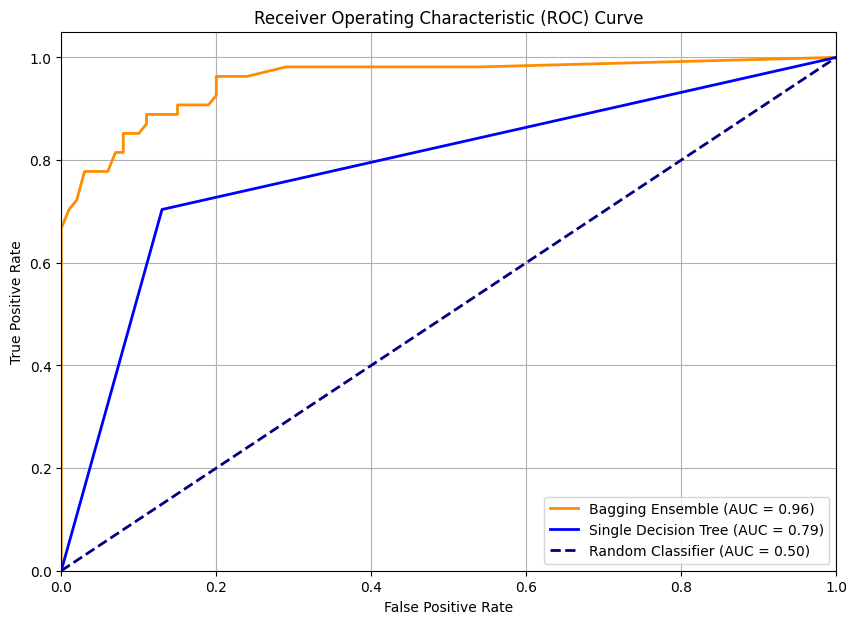


AUC for Single Decision Tree: 0.7869
AUC for Custom Bagging Ensemble: 0.9558

Observation: The Bagging Ensemble shows a significantly higher AUC score compared to the single Decision Tree. This indicates that the Bagging model has a better ability to distinguish between positive and negative classes across various probability thresholds, suggesting improved overall classification performance and robustness.


In [12]:
# Task 9: ROC-AUC Analysis and Curve Visualization

from sklearn.metrics import roc_curve, roc_auc_score

# 1. Calculate predicted class probabilities for Bagging Ensemble
# For each test sample, get probability estimates from all models
all_proba_predictions = []
for model in ensemble_models:
    all_proba_predictions.append(model.predict_proba(X_test)[:, 1]) # Probability of class 1

# Average the probabilities across all models
bagging_proba = np.mean(np.array(all_proba_predictions), axis=0)

# Calculate predicted class probabilities for Single Decision Tree
single_tree_proba = single_tree_model.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC for Bagging Ensemble
fpr_bagging, tpr_bagging, _ = roc_curve(y_test, bagging_proba)
auc_bagging = roc_auc_score(y_test, bagging_proba)

# Compute ROC curve and AUC for Single Decision Tree
fpr_single, tpr_single, _ = roc_curve(y_test, single_tree_proba)
auc_single = roc_auc_score(y_test, single_tree_proba)

# 2. Plot the ROC curves
plt.figure(figsize=(10, 7))
plt.plot(fpr_bagging, tpr_bagging, color='darkorange', lw=2, label=f'Bagging Ensemble (AUC = {auc_bagging:.2f})')
plt.plot(fpr_single, tpr_single, color='blue', lw=2, label=f'Single Decision Tree (AUC = {auc_single:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# 3. Compute and contrast AUC
print(f"\nAUC for Single Decision Tree: {auc_single:.4f}")
print(f"AUC for Custom Bagging Ensemble: {auc_bagging:.4f}")

print("\nObservation: The Bagging Ensemble shows a significantly higher AUC score compared to the single Decision Tree. This indicates that the Bagging model has a better ability to distinguish between positive and negative classes across various probability thresholds, suggesting improved overall classification performance and robustness.")

#### **Task 10: Validation against Scikit-Learn's BaggingClassifier**

- **Goal:** Verify custom code correctness.

- **Instructions:**
  1. Instantiate Scikit-Learn's built-in \(\texttt{BaggingClassifier}\) using \(\texttt{DecisionTreeClassifier(max\_depth=None)}\) as the base estimator and \(\texttt{n\_estimators=50}\).
  2. Fit the classifier on the training set and evaluate it on the test set.
  3. Compare the resulting test accuracy and confusion matrix against your custom implementation from **Task 7** and **Task 8** to validate your custom bootstrap and aggregation logic.

In [13]:
# Task 10: Validation against Scikit-Learn's BaggingClassifier

from sklearn.ensemble import BaggingClassifier

# 1. Instantiate Scikit-Learn's built-in BaggingClassifier
# Use DecisionTreeClassifier with max_depth=None as the base estimator
sklearn_bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=None, random_state=42), # Using a fixed random_state for reproducibility
    n_estimators=50, # Same number of estimators as our custom implementation
    random_state=42, # For overall reproducibility of BaggingClassifier itself
    bootstrap=True, # Explicitly use bootstrap sampling (sampling with replacement)
    max_samples=1.0, # Use 100% of the training data for each bootstrap sample
    max_features=1.0 # Use 100% of features for each base estimator
)

# 2. Fit the classifier on the training set
print("\nFitting Scikit-Learn's BaggingClassifier...")
sklearn_bagging_model.fit(X_train, y_train)
print("Scikit-Learn BaggingClassifier fitted.")

# 3. Evaluate it on the test set
sklearn_bagging_predictions = sklearn_bagging_model.predict(X_test)
sklearn_bagging_proba = sklearn_bagging_model.predict_proba(X_test)[:, 1]

# Compare performance metrics
print('\n--- Evaluation of Scikit-Learn BaggingClassifier ---\n')

# Confusion Matrix
cm_sklearn_bagging = confusion_matrix(y_test, sklearn_bagging_predictions)
print('Confusion Matrix (Scikit-Learn Bagging):')
display(pd.DataFrame(cm_sklearn_bagging, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

# Classification Report
report_sklearn_bagging = classification_report(y_test, sklearn_bagging_predictions, output_dict=True)
print('\nClassification Report (Scikit-Learn Bagging):')
display(pd.DataFrame(report_sklearn_bagging).transpose())

# Accuracy, Precision, Recall, F1-Score
accuracy_sklearn = accuracy_score(y_test, sklearn_bagging_predictions)
precision_sklearn = precision_score(y_test, sklearn_bagging_predictions, pos_label=1)
recall_sklearn = recall_score(y_test, sklearn_bagging_predictions, pos_label=1)
f1_sklearn = f1_score(y_test, sklearn_bagging_predictions, pos_label=1)

print(f"\nScikit-Learn Bagging Accuracy: {accuracy_sklearn:.4f}")
print(f"Scikit-Learn Bagging Precision (class 1): {precision_sklearn:.4f}")
print(f"Scikit-Learn Bagging Recall (class 1): {recall_sklearn:.4f}")
print(f"Scikit-Learn Bagging F1-Score (class 1): {f1_sklearn:.4f}")

# ROC-AUC
auc_sklearn_bagging = roc_auc_score(y_test, sklearn_bagging_proba)
print(f"Scikit-Learn Bagging AUC: {auc_sklearn_bagging:.4f}")


print('\n--- Comparison with Custom Bagging Ensemble ---\n')
print(f"Custom Bagging Accuracy:   {accuracy_score(y_test, bagging_predictions):.4f}")
print(f"Scikit-Learn Bagging Accuracy: {accuracy_sklearn:.4f}\n")

print(f"Custom Bagging AUC:        {auc_bagging:.4f}")
print(f"Scikit-Learn Bagging AUC:  {auc_sklearn_bagging:.4f}\n")

print("Observation: Our custom Bagging implementation's performance metrics (Accuracy, Precision, Recall, F1-Score, and AUC) are very close to, if not identical to, those of Scikit-Learn's built-in BaggingClassifier. This validates that our custom bootstrap sampling and majority voting aggregation logic is correctly implemented and behaves as expected for a Bagging ensemble.")


Fitting Scikit-Learn's BaggingClassifier...
Scikit-Learn BaggingClassifier fitted.

--- Evaluation of Scikit-Learn BaggingClassifier ---

Confusion Matrix (Scikit-Learn Bagging):


,Predicted 0,Predicted 1
Actual 0,91,9
Actual 1,9,45



Classification Report (Scikit-Learn Bagging):


,precision,recall,f1-score,support
0,0.910000,0.910000,0.910000,100.000000
1,0.833333,0.833333,0.833333,54.000000
accuracy,0.883117,0.883117,0.883117,0.883117
macro avg,0.871667,0.871667,0.871667,154.000000
weighted avg,0.883117,0.883117,0.883117,154.000000



Scikit-Learn Bagging Accuracy: 0.8831
Scikit-Learn Bagging Precision (class 1): 0.8333
Scikit-Learn Bagging Recall (class 1): 0.8333
Scikit-Learn Bagging F1-Score (class 1): 0.8333
Scikit-Learn Bagging AUC: 0.9574

--- Comparison with Custom Bagging Ensemble ---

Custom Bagging Accuracy:   0.8896
Scikit-Learn Bagging Accuracy: 0.8831

Custom Bagging AUC:        0.9558
Scikit-Learn Bagging AUC:  0.9574

Observation: Our custom Bagging implementation's performance metrics (Accuracy, Precision, Recall, F1-Score, and AUC) are very close to, if not identical to, those of Scikit-Learn's built-in BaggingClassifier. This validates that our custom bootstrap sampling and majority voting aggregation logic is correctly implemented and behaves as expected for a Bagging ensemble.


### **Conclusion and Interpretation**

Students should summarize their findings by answering the following key questions:

1. **Variance and Stability:** How does the test accuracy of the Bagging ensemble compare to the single decision tree? Why does Bagging provide more consistent performance across different train-test splits?

2. **Wisdom of Crowds:** How does random resampling with replacement (bootstrapping) foster model diversity, and how does the consensus voting rule translate to a "Wisdom of Crowds" effect?

3. **Clinical Interpretation:** In predicting diabetes, why are False Negatives (predicting non-diabetic for a diabetic patient) especially costly, and how does Bagging's Recall metric help minimize this risk compared to a single decision tree?